Objective

The objective of this project is to model short-term interest rates using the Vasicek and Cox-Ingersoll-Ross (CIR) models. Parameters are estimated using Maximum Likelihood Estimation (MLE), future interest-rate paths are simulated using Monte Carlo methods, and the models are applied to zero-coupon bond pricing and stress testing.

In [1]:
import numpy as np
import pandas as pda
import matplotlib.pyplot as plt
from  scipy.stats import norm
from scipy.optimize import minimize
import pandas_datareader as pdr
import yfinance as yf
import datetime as dt
from scipy.stats import linregress
from scipy.stats import ncx2

## Data Collection and Preprocessing

Historical US 10-Year Treasury Yield data (^TNX) is downloaded from Yahoo Finance. The yield is converted from percentage form to decimal form and used as the short-term interest rate proxy for model calibration.

In [2]:
startdate= dt.datetime(2010, 1, 1)
enddate = dt.datetime.now()
df= yf.download('^TNX', startdate, enddate)
df= df.dropna()
rates= df['Close']/ 100
dt_step= 1/252
print(rates.tail())


[*********************100%***********************]  1 of 1 completed

Ticker         ^TNX
Date               
2026-05-29  0.04453
2026-06-01  0.04475
2026-06-02  0.04455
2026-06-03  0.04491
2026-06-04  0.04473


## Exploratory Data Analysis

The historical behavior of Treasury yields is examined to understand long-term trends and interest rate dynamics.

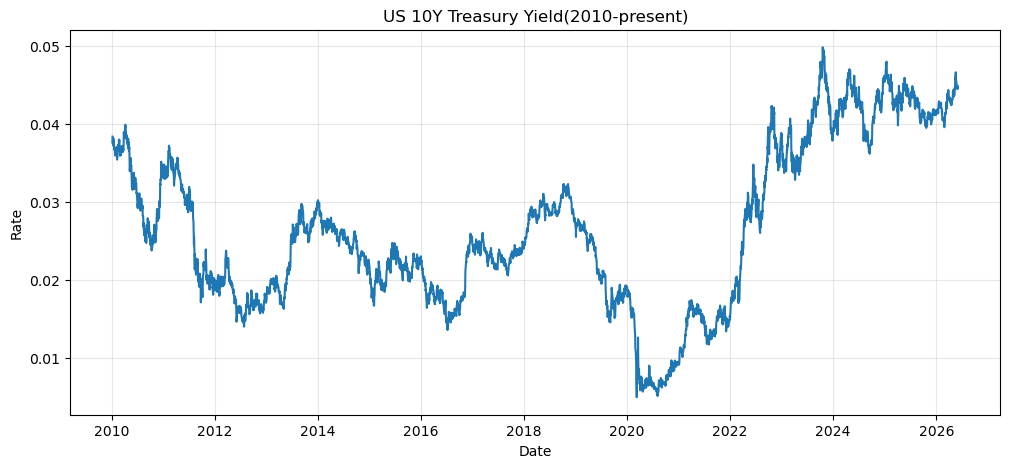

In [3]:
plt.figure(figsize=(12,5))
plt.plot(rates)
plt.title('US 10Y Treasury Yield(2010-present)')
plt.xlabel('Date')
plt.ylabel('Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout
plt.show()


    


In [4]:
r= rates.values.flatten()
print(type(r))
print(r.shape)


<class 'numpy.ndarray'>
(4128,)


In [5]:
r_t= r[:-1]
r_next= r[1:]
dt= 1/252
b0= np.mean(r)
dr= np.diff(r)
σ0= np.std(dr)/ np.sqrt(dt)
beta = linregress(r_t, r_next).slope
a0= -np.log(beta)/dt
print(beta)




0.9988587098147673


## Vasicek Model Calibration

The Vasicek model assumes mean-reverting interest rates with normally distributed shocks. Parameters are estimated using Maximum Likelihood Estimation (MLE).

In [6]:
def neg_log_likelihood(params, r_t, dt, r_next):
    a, b, σ = params
    mean = r_t*np.exp(-a*dt) + b*(1- np.exp(-a*dt))
    variance = (σ**2/(2*a))* (1-np.exp(-2*a*dt))
    loglik = (-0.5*np.log(2*np.pi*variance)- ((r_next - mean)**2)/ (2*variance))
    return -np.sum(loglik)


In [7]:
initial_guess= [ a0, b0, σ0]
result = minimize(neg_log_likelihood, initial_guess, args=(r_t,dt,r_next), bounds=[(0.0001, None), (None, None), (0.0001, None)])

In [8]:
print(result)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -25232.37050711648
        x: [ 2.878e-01  2.647e-02  8.501e-03]
      nit: 2
      jac: [-3.638e-04 -2.509e+01  1.985e+00]
     nfev: 20
     njev: 5
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


In [9]:
a_hat, b_hat, σ_hat = result.x
print("Speed of Mean Reversion(a):", a_hat)
print("Long Run Mean (b):", b_hat)
print("Volatility (σ):", σ_hat)


Speed of Mean Reversion(a): 0.28776937206876074
Long Run Mean (b): 0.026472842563428557
Volatility (σ): 0.008500539686215143


In [10]:
r0= r[-1]
T= 1
dt= 1/252
N= int(T/dt)

In [11]:
rates_path= [r0]
for i in range (N):
    Z= np.random.normal()
    rt= (rates_path[-1] + a_hat*(b_hat- rates_path[-1])*dt+ σ_hat*np.sqrt(dt)*Z)
    rates_path.append(rt)
    

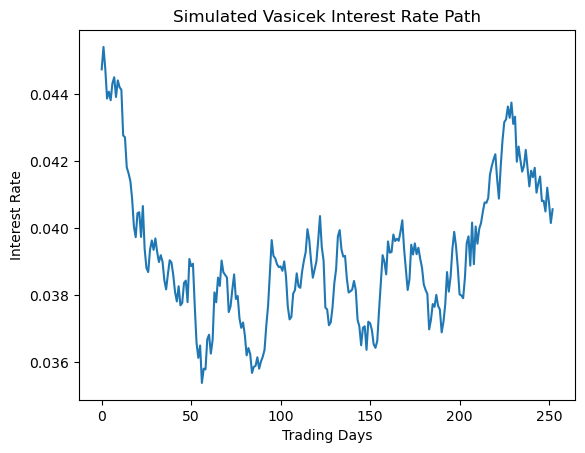

In [12]:
plt.plot(rates_path)
plt.title("Simulated Vasicek Interest Rate Path")
plt.xlabel("Trading Days")
plt.ylabel("Interest Rate")
plt.show()


## Monte Carlo Simulation

Using the estimated parameters, future interest rate paths are simulated over a one-year horizon to analyze possible interest rate scenarios.

In [13]:
num_paths= 1000
all_paths= []
for j in range(num_paths):
    rates_path= [r0]
    for i in range(N):
          Z= np.random.normal()
          rt= (rates_path[-1] + a_hat*(b_hat- rates_path[-1])*dt+ σ_hat*np.sqrt(dt)*Z)
          rates_path.append(rt)
    all_paths.append(rates_path)
mean_path = np.mean(all_paths, axis= 0)
        

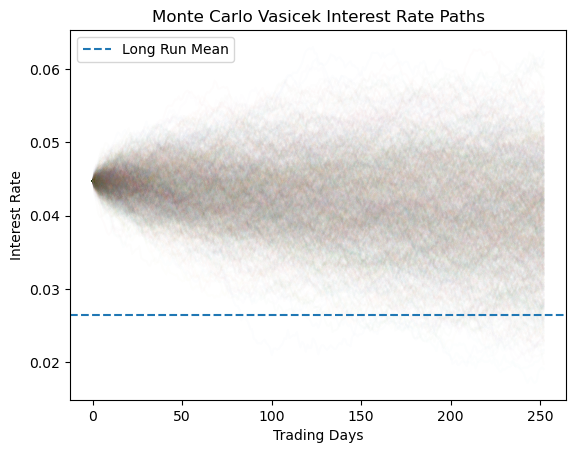

In [14]:
for i in range (num_paths):
    plt.plot(all_paths[i], alpha= 0.01)
plt.axhline(y=b_hat, linestyle="--", label="Long Run Mean")
plt.title("Monte Carlo Vasicek Interest Rate Paths")
plt.xlabel("Trading Days")
plt.ylabel("Interest Rate")
plt.legend()
plt.show()

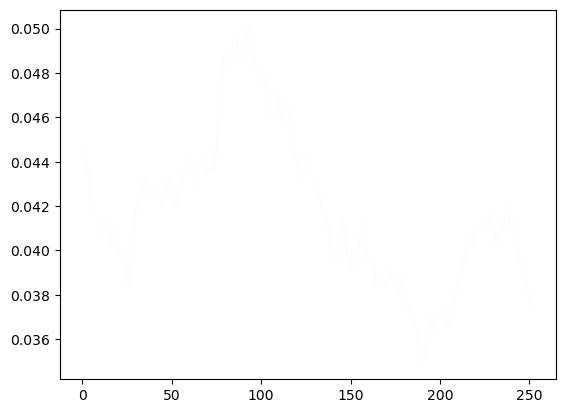

In [15]:
plt.plot(all_paths[i], alpha= 0.01)

## Stress Testing Analysis

Stress scenarios of ±50 basis points and ±100 basis points are applied to the long-run mean parameter to assess the sensitivity of future interest rate paths and bond prices.

In [16]:
base= b_hat
up_50= b_hat+ 0.005
down_50= b_hat - 0.005
up_100= b_hat + 0.01
down_100= b_hat - 0.01


In [17]:
scenarios= {"Base": base, "+50bps": up_50, "-50bps": down_50, "+100bps": up_100, "-100bps": down_100}
print(scenarios)

{'Base': np.float64(0.026472842563428557), '+50bps': np.float64(0.031472842563428555), '-50bps': np.float64(0.021472842563428556), '+100bps': np.float64(0.03647284256342856), '-100bps': np.float64(0.016472842563428555)}


In [18]:
scenario_paths={}
stress_results= {}
for name, b in scenarios.items():
    all_paths=[]
    for j in range(num_paths):
        rates_path= [r0]
        for i in range(N):
            Z= np.random.normal()
            rt= (rates_path[-1] + a_hat*(b- rates_path[-1])*dt+ σ_hat*np.sqrt(dt)*Z)
            rates_path.append(rt)
        all_paths.append(rates_path)
    all_paths= np.array(all_paths)
    scenario_paths[name]= all_paths
    stress_results[name] = np.mean(all_paths, axis=0)
        
         

In [19]:
print(stress_results.keys())

dict_keys(['Base', '+50bps', '-50bps', '+100bps', '-100bps'])


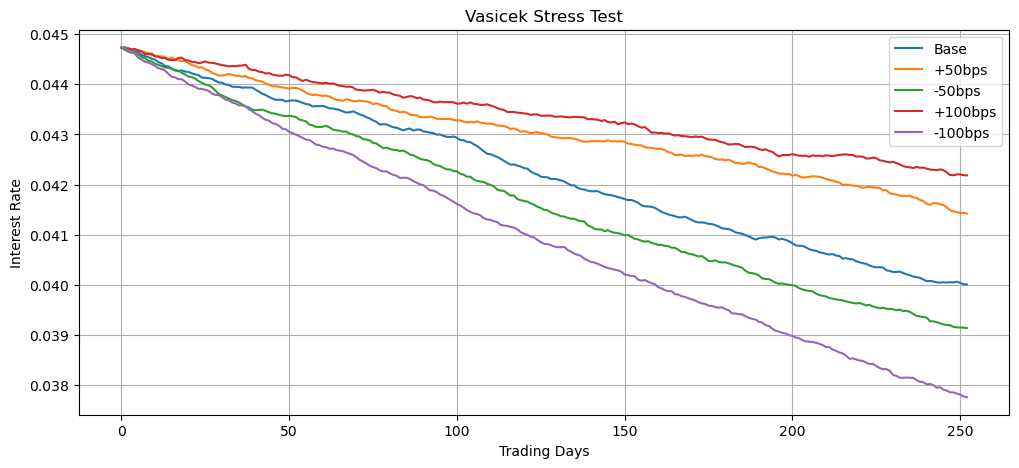

In [20]:
plt.figure(figsize=(12,5))
for name, mean_path in stress_results.items():
    plt.plot(mean_path, label= name)
plt.title("Vasicek Stress Test")
plt.xlabel("Trading Days")
plt.ylabel("Interest Rate")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
for name, mean_path in stress_results.items():
    print(f"{name}:, {mean_path[-1]:.4%}")



Base:, 4.0011%
+50bps:, 4.1425%
-50bps:, 3.9139%
+100bps:, 4.2186%
-100bps:, 3.7761%


In [22]:
base_paths= scenario_paths["Base"]
discount_factors = np.exp(-np.sum(base_paths[:, :-1]*dt, axis=1))

In [23]:
bond_price= np.mean(discount_factors)
print(" 1 year Zero Coupon Bond Prices:", bond_price)

 1 year Zero Coupon Bond Prices: 0.9586377684457762


In [24]:
for name, mean_path in stress_results.items():
    discount_factor = np.exp(-np.sum(mean_path[:-1]*dt))
    print(name, discount_factor)
    

Base 0.958628378189784
+50bps 0.9578511828999269
-50bps 0.9591765202374275
+100bps 0.9575208935230884
-100bps 0.9598132488008786


## CIR Model Calibration

The Cox-Ingersoll-Ross (CIR) model extends the Vasicek framework by ensuring non-negative interest rates through a square-root diffusion process. Parameters are estimated using Maximum Likelihood Estimation.

In [25]:
def cir_neg_log_likelihood(params, r_t, r_next, dt): 
    a, b, σ = params
    if a<=0 or b<=0 or σ<=0:
       return 1e10
    if  2*a*b <= σ**2:
        return 1e10
    c= (2 * a) / (σ**2 * (1 - np.exp(-a * dt)))
    d= 4*a*b/(σ**2)
    nc = 2 * c * r_t * np.exp(-a * dt)
    y= 2*c*r_next
    pdf= 2*c*ncx2.pdf(y, d, nc)
    pdf= np.maximum(pdf, 1e-300)
    return -np.sum(np.log(pdf)) 
       
       

In [26]:
initial_guess= [a_hat,b_hat, σ_hat]

In [27]:
bounds= [(1e-4, None), (1e-4, None), (1e-4, None)]

In [28]:
cir_result= minimize(cir_neg_log_likelihood, initial_guess, args=(r_t, r_next, dt), bounds=bounds, method= 'L-BFGS-B')

In [29]:
a_cir, b_cir,σ_cir= cir_result.x
print("CIR speed of mean reversion:", a_cir)
print("CIR long term mean:", b_cir)
print("CIR volatility:", σ_cir)

CIR speed of mean reversion: 0.28779854333620986
CIR long term mean: 0.027916977729960716
CIR volatility: 0.05623821018679885


In [30]:
print("Vasicek")
print(a_hat, b_hat, σ_hat)

print("CIR")
print(a_cir, b_cir,σ_cir)

Vasicek
0.28776937206876074 0.026472842563428557 0.008500539686215143
CIR
0.28779854333620986 0.027916977729960716 0.05623821018679885


In [31]:
print(cir_result)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -25108.46852670188
        x: [ 2.878e-01  2.792e-02  5.624e-02]
      nit: 22
      jac: [-1.390e-01  2.132e-01  8.629e-01]
     nfev: 100
     njev: 25
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


In [32]:
num_paths= 1000
cir_paths= np.zeros((num_paths, N+1))
for j in range(num_paths):
    rt=r0
    cir_paths[j,0] = rt
    for i in range(N):
          Z= np.random.normal()
          rt= rt + a_cir*(b_cir -rt)*dt+ σ_cir*np.sqrt(max(rt,0))*np.sqrt(dt)*Z
          rt = max(rt,0)
          cir_paths[j, i+1] = rt


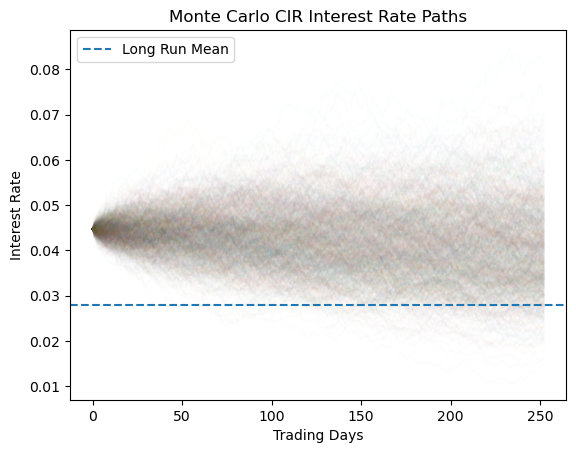

In [33]:
for i in range (num_paths):
    plt.plot(cir_paths[i], alpha= 0.01)
plt.axhline(y=b_cir, linestyle="--", label="Long Run Mean")
plt.title("Monte Carlo CIR Interest Rate Paths")
plt.xlabel("Trading Days")
plt.ylabel("Interest Rate")
plt.legend()
plt.show()

In [34]:
discount_factors_cir = np.exp(-np.sum(cir_paths[:, :-1]*dt, axis=1))
cir_bond_price= np.mean(discount_factors_cir)
print("Vasicen:", bond_price)
print("CIR:", cir_bond_price)

Vasicen: 0.9586377684457762
CIR: 0.9585765787855139


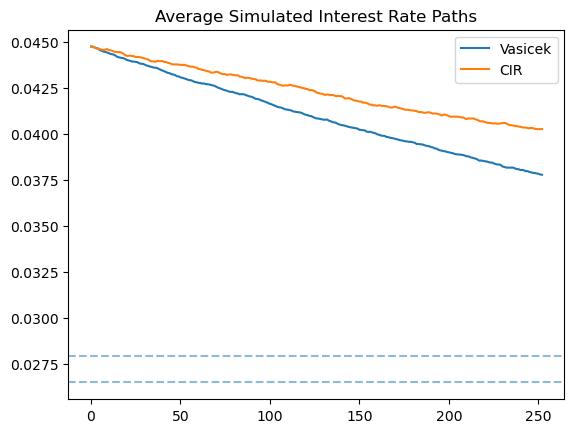

In [35]:
vasicek_mean= np.mean(all_paths, axis=0)
cir_mean= np.mean(cir_paths, axis=0)
plt.plot(vasicek_mean, label="Vasicek")
plt.plot(cir_mean, label="CIR")
plt.axhline(y=b_hat, linestyle="--", alpha=0.5)
plt.axhline(y=b_cir, linestyle="--", alpha=0.5)
plt.legend()
plt.title("Average Simulated Interest Rate Paths")
plt.show()

## Comparison of Vasicek and CIR Models

| Feature | Vasicek | CIR |
|----------|---------|------|
| Mean Reversion | Yes | Yes |
| Negative Rates Possible | Yes | No |
| Volatility | Constant | Rate-dependent |
| Calibration Complexity | Lower | Higher |
| Realism | Moderate | Higher |
| Bond Price (1 Year) | 0.9586 | 0.9582 |

## Model Assumptions and Limitations

### Vasicek Model

| Assumptions | Limitations |
|------------|-------------|
| Interest rates follow a mean-reverting process. | Allows negative interest rates. |
| Speed of mean reversion remains constant over time. | Assumes constant volatility. |
| Interest rate shocks are normally distributed. | May underestimate extreme market movements. |
| Long-run mean remains constant throughout the sample period. | Cannot fully capture complex yield curve dynamics. |
| Markets are assumed to be arbitrage-free. | Model parameters may change across economic regimes. |

### CIR Model

| Assumptions | Limitations |
|------------|-------------|
| Interest rates follow a mean-reverting process. | Calibration is more computationally intensive. |
| Volatility depends on the level of interest rates. | Assumes parameters remain constant over time. |
| Interest rates remain non-negative. | May not fully capture sudden regime shifts. |
| Long-run mean and speed of mean reversion are constant. | Single-factor structure ignores other economic variables. |
| Markets are assumed to be arbitrage-free. | May not perfectly fit the entire yield curve. |


## Conclusion

Both Vasicek and CIR models successfully capture mean-reverting behavior in interest rates. Monte Carlo simulations were used to generate future rate paths and estimate bond prices. Stress testing demonstrated the impact of shifts in interest rate expectations on bond valuation and future rate dynamics.